## Train A Test A

### Classification

Category distribution:
4    6247
0    5229
3     246
2     110
5      38
6      32
1      30
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.66      0.65      0.65      1051
      Button       1.00      0.71      0.83         7
        Door       0.74      0.63      0.68        27
      Motion       0.62      0.57      0.59        42
      Socket       0.71      0.74      0.72      1238
 Temperature       1.00      0.50      0.67        10
   Vibration       0.60      0.25      0.35        12

    accuracy                           0.69      2387
   macro avg       0.76      0.58      0.64      2387
weighted avg       0.69      0.69      0.69      2387

Macro F1-Score: 0.6431


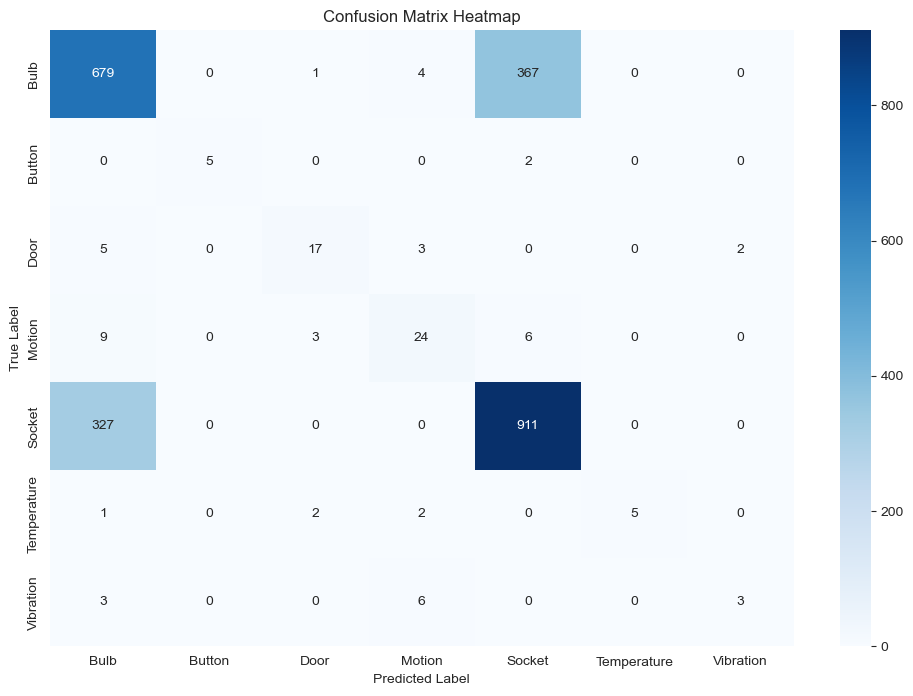

In [26]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
# Calculated Macro Average F1-Score
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
15    1702
14    1345
5     1340
13    1339
12    1163
8     1155
6     1034
9      851
7      827
10     720
11     173
1       39
20      38
2       33
4       32
3       31
0       30
19      25
16      23
18      17
17      15
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       1.00      0.71      0.83         7
        Aqara Door 1       0.45      0.71      0.56         7
        Aqara Door 2       0.67      0.50      0.57        12
        Aqara Motion       0.80      0.57      0.67         7
     Aqara Vibration       0.78      0.58      0.67        12
       Ledvance Bulb       0.35      0.33      0.34       258
Ledvance Smart+ Plug       0.32      0.32      0.32       221
    Ledvance Z3 Plug       0.23      0.21      0.22       168
           Moes Bulb       0.79      0.89      0.84       235
      Philips Lamp 1       0.16      0.17      0.17       170
      Philips Lamp 2       0.22      

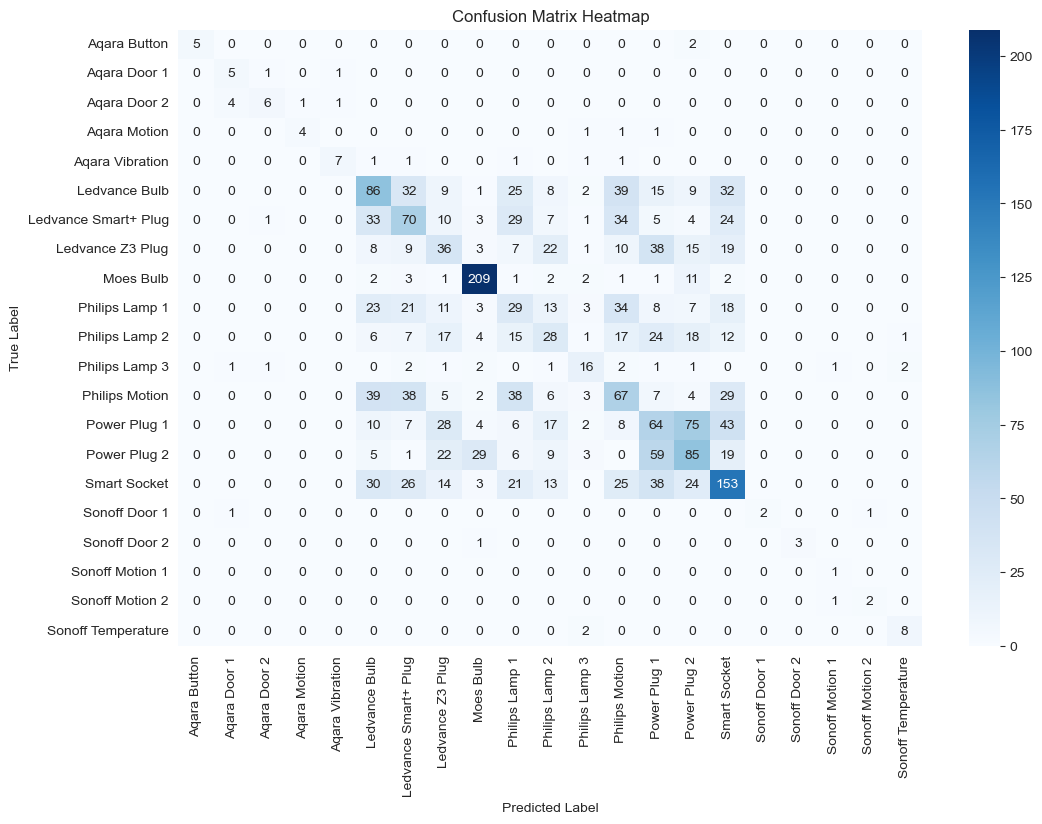

In [27]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train B Test B

### Classification

Category distribution:
4    9042
0    6639
3     597
2     195
5     110
1     101
6      40
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.63      0.63      0.63      1304
      Button       0.80      0.67      0.73        18
        Door       0.89      0.77      0.82        43
      Motion       0.86      0.79      0.82       104
      Socket       0.73      0.74      0.74      1853
 Temperature       0.53      0.56      0.54        18
   Vibration       0.00      0.00      0.00         5

    accuracy                           0.70      3345
   macro avg       0.63      0.59      0.61      3345
weighted avg       0.70      0.70      0.70      3345

Macro F1-Score: 0.6120


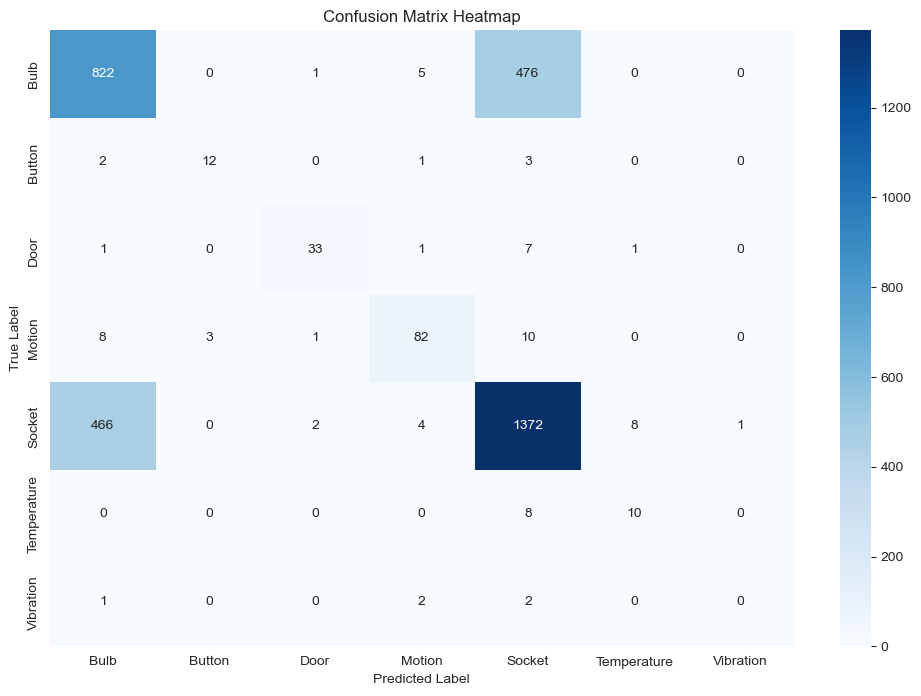

In [28]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
15    2759
13    2643
5     1789
8     1506
14    1394
7     1345
9     1310
11    1269
6      901
10     765
12     402
3      118
20     110
0      101
16      59
18      56
17      53
1       53
4       40
2       30
19      21
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.70      0.78      0.74        18
        Aqara Door 1       0.67      0.83      0.74        12
        Aqara Door 2       1.00      0.88      0.93         8
        Aqara Motion       0.70      1.00      0.82        16
     Aqara Vibration       0.00      0.00      0.00         5
       Ledvance Bulb       0.30      0.32      0.31       351
Ledvance Smart+ Plug       0.12      0.11      0.11       189
    Ledvance Z3 Plug       0.11      0.09      0.10       285
           Moes Bulb       0.58      0.61      0.59       319
      Philips Lamp 1       0.32      0.32      0.32       261
      Philips Lamp 2       0.14      

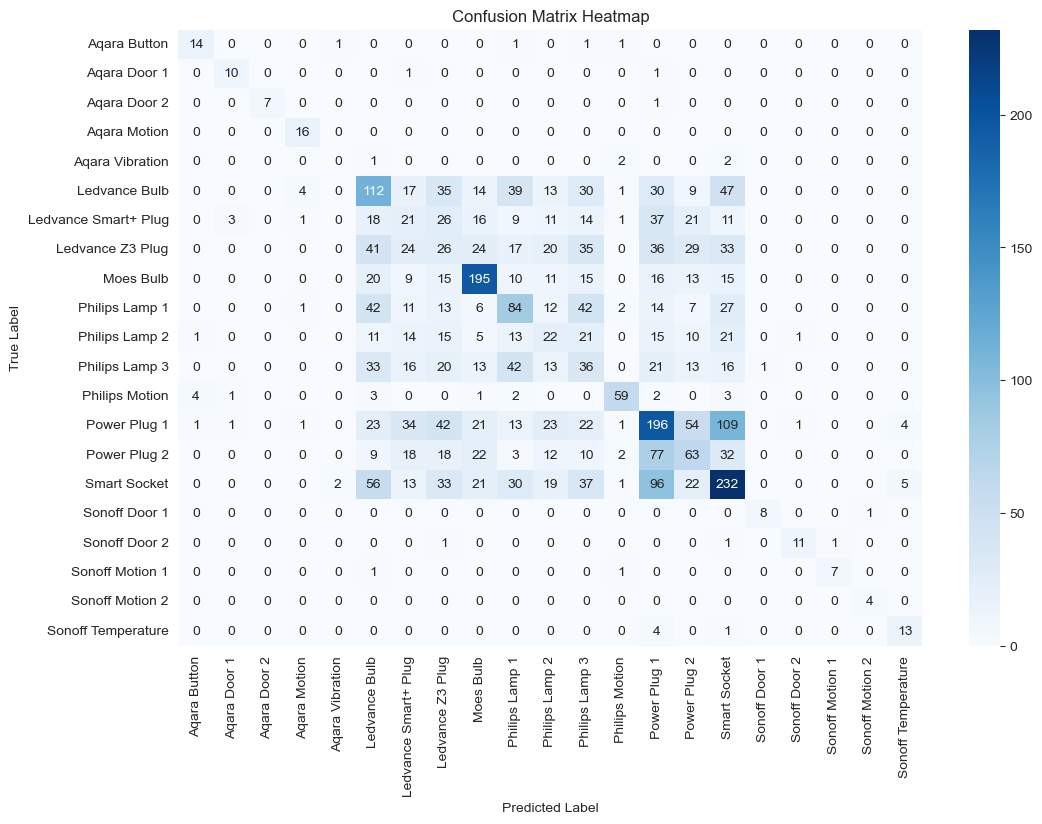

In [29]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train A Test B

### Classification

Category distribution:
4    6247
0    5229
3     246
2     110
5      38
6      32
1      30
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.54      0.50      0.52      6639
      Button       0.02      0.01      0.01       101
        Door       0.35      0.13      0.19       195
      Motion       0.52      0.51      0.51       597
      Socket       0.66      0.72      0.69      9042
 Temperature       0.33      0.15      0.21       110
   Vibration       0.00      0.00      0.00        40

    accuracy                           0.61     16724
   macro avg       0.35      0.29      0.31     16724
weighted avg       0.60      0.61      0.60     16724

Macro F1-Score: 0.3054


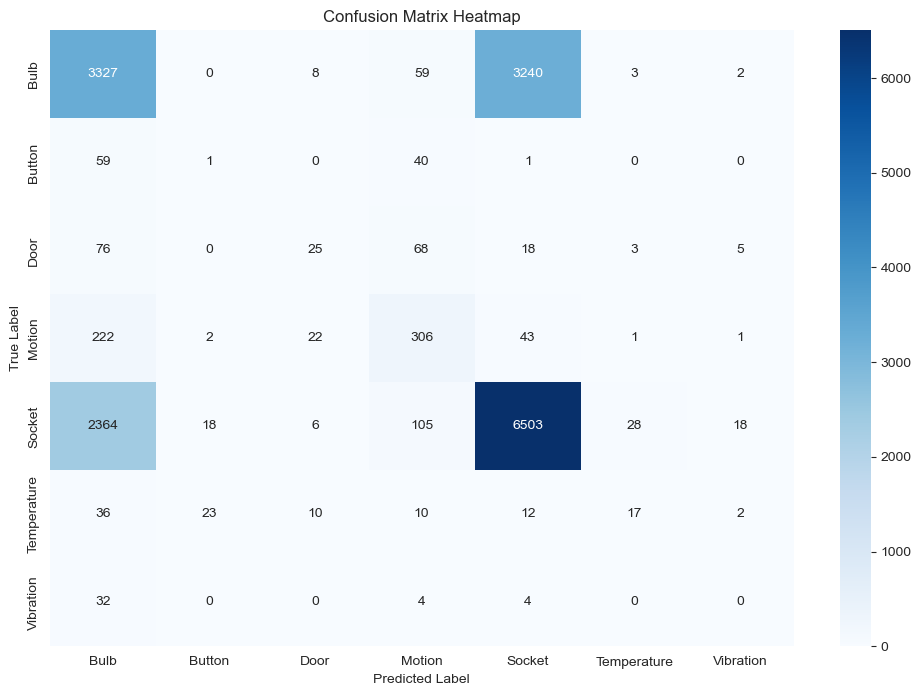

In [30]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
15    1702
14    1345
5     1340
13    1339
12    1163
8     1155
6     1034
9      851
7      827
10     720
11     173
1       39
20      38
2       33
4       32
3       31
0       30
19      25
16      23
18      17
17      15
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.04      0.03      0.03       101
        Aqara Door 1       0.00      0.00      0.00        53
        Aqara Door 2       0.71      0.17      0.27        30
        Aqara Motion       0.27      0.13      0.17       118
     Aqara Vibration       0.02      0.03      0.02        40
       Ledvance Bulb       0.32      0.29      0.30      1789
Ledvance Smart+ Plug       0.06      0.07      0.06       901
    Ledvance Z3 Plug       0.14      0.17      0.15      1345
           Moes Bulb       0.49      0.37      0.42      1506
      Philips Lamp 1       0.19      0.14      0.16      1310
      Philips Lamp 2       0.10      

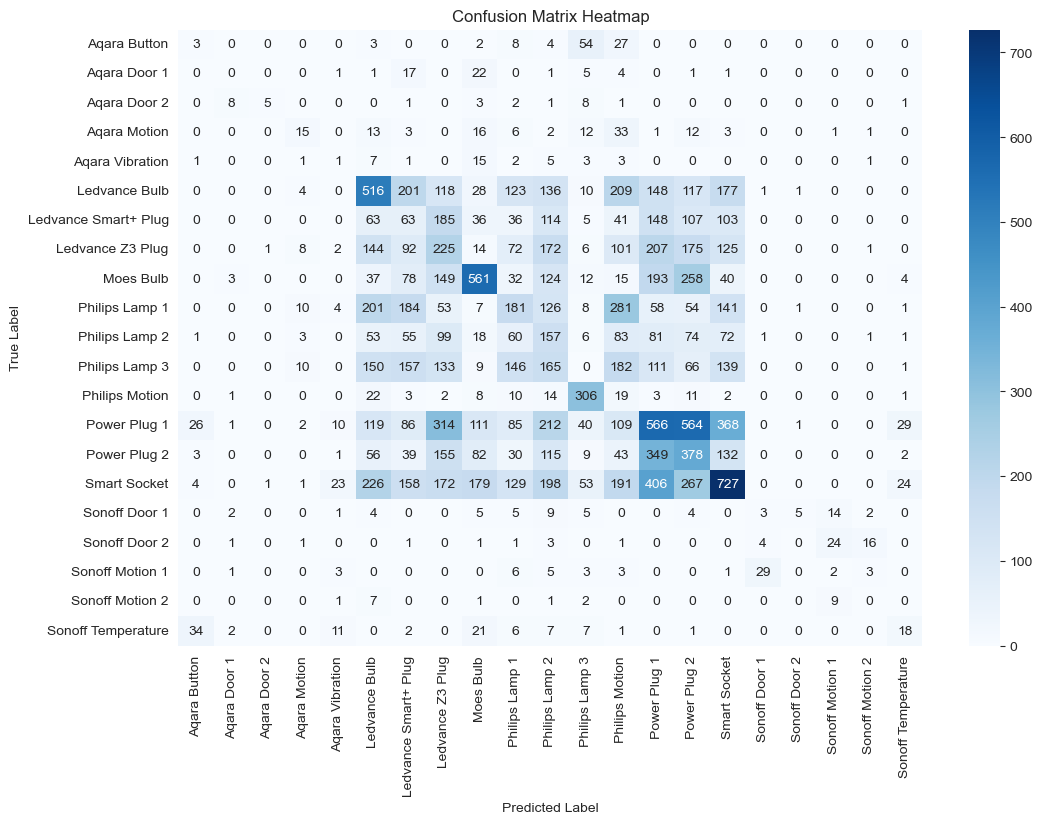

In [31]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


## Train B Test A

### Classification

Category distribution:
4    9042
0    6639
3     597
2     195
5     110
1     101
6      40
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.61      0.60      0.60      5229
      Button       0.33      0.03      0.06        30
        Door       0.52      0.60      0.56       110
      Motion       0.55      0.36      0.44       246
      Socket       0.66      0.69      0.68      6247
 Temperature       0.38      0.47      0.42        38
   Vibration       0.00      0.00      0.00        32

    accuracy                           0.64     11932
   macro avg       0.44      0.39      0.39     11932
weighted avg       0.63      0.64      0.63     11932

Macro F1-Score: 0.3933


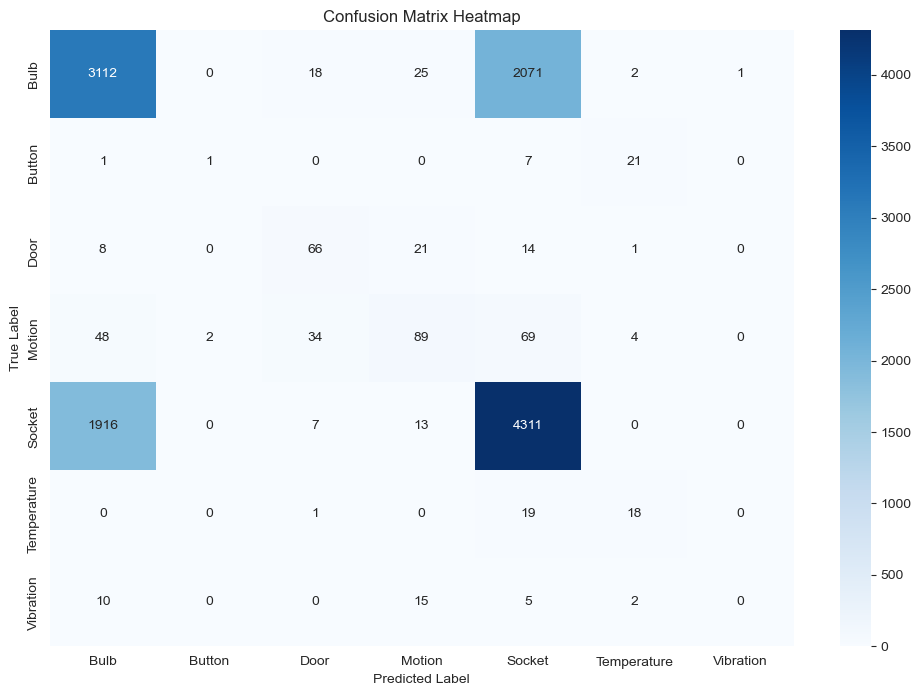

In [32]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]
y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes


class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
15    2759
13    2643
5     1789
8     1506
14    1394
7     1345
9     1310
11    1269
6      901
10     765
12     402
3      118
20     110
0      101
16      59
18      56
17      53
1       53
4       40
2       30
19      21
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.22      0.07      0.10        30
        Aqara Door 1       0.00      0.00      0.00        39
        Aqara Door 2       0.34      0.91      0.50        33
        Aqara Motion       0.30      0.19      0.24        31
     Aqara Vibration       0.00      0.00      0.00        32
       Ledvance Bulb       0.32      0.37      0.34      1340
Ledvance Smart+ Plug       0.10      0.06      0.08      1034
    Ledvance Z3 Plug       0.14      0.14      0.14       827
           Moes Bulb       0.56      0.62      0.59      1155
      Philips Lamp 1       0.16      0.24      0.19       851
      Philips Lamp 2       0.14      

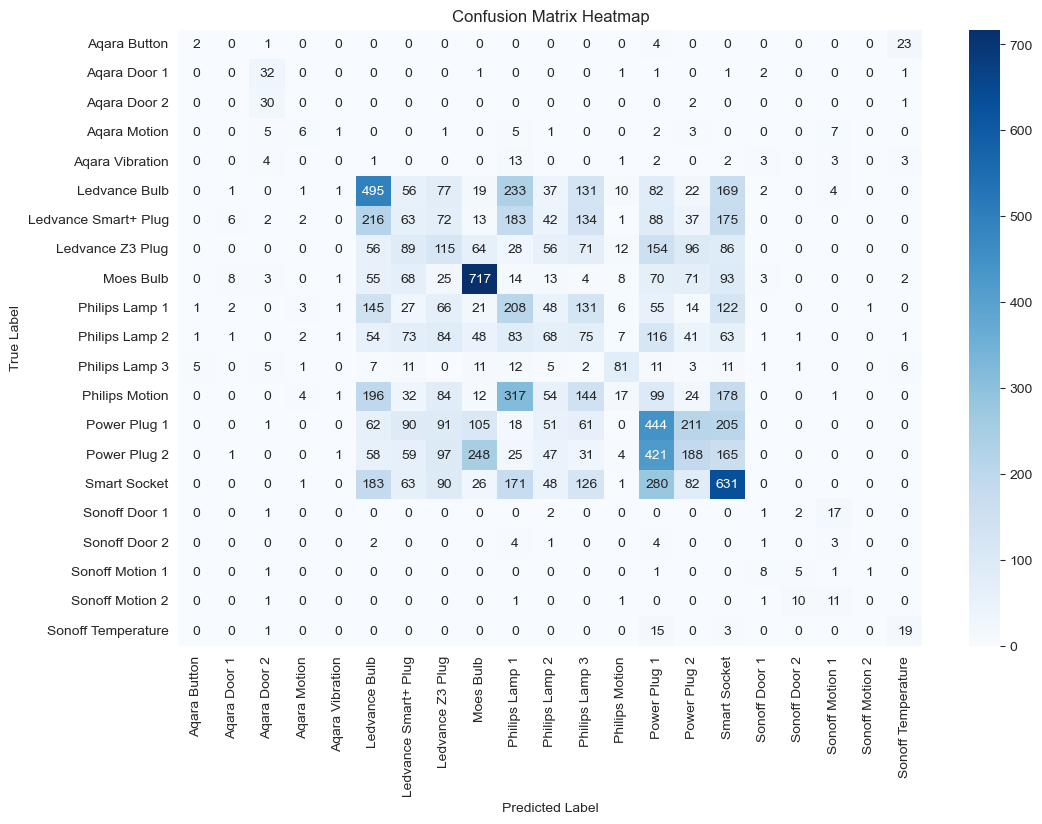

In [33]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()
